# VERİ YÜKLEME VE HAZIRLIK

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd

In [28]:
kolon_isimleri = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

dosya_yolu = '/content/drive/MyDrive/MakineProje/heart_disease/processed.cleveland.data'

df = pd.read_csv(dosya_yolu, names=kolon_isimleri)
print("Veri başarıyla yüklendi. Toplam satır:", len(df))
df.head()

Veri başarıyla yüklendi. Toplam satır: 303


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


# GÖREV 1: VERİ ÖN İŞLEME (Eksik Veri ve Aykırı Değer Temizliği)

In [30]:
import numpy as np

In [31]:
# 1. '?' işaretlerini Numpy'ın anladığı boş değer (NaN) ile değiştiriyoruz
df.replace('?', np.nan, inplace=True)

# 2. İçinde boş değer (NaN) oluşan satırları (hastaları) siliyoruz
df.dropna(inplace=True)

# 3. 'ca' ve 'thal' sütunlarını metinden sayı formatına (float) çeviriyoruz
df['ca'] = df['ca'].astype(float)
df['thal'] = df['thal'].astype(float)

# 4. Target sütunundaki 1, 2, 3, 4 değerlerini 1'e çeviriyoruz (Hasta=1, Sağlıklı=0)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Yaptığımız değişiklikler işe yaramış mı diye son duruma bakalım:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 34.8 KB


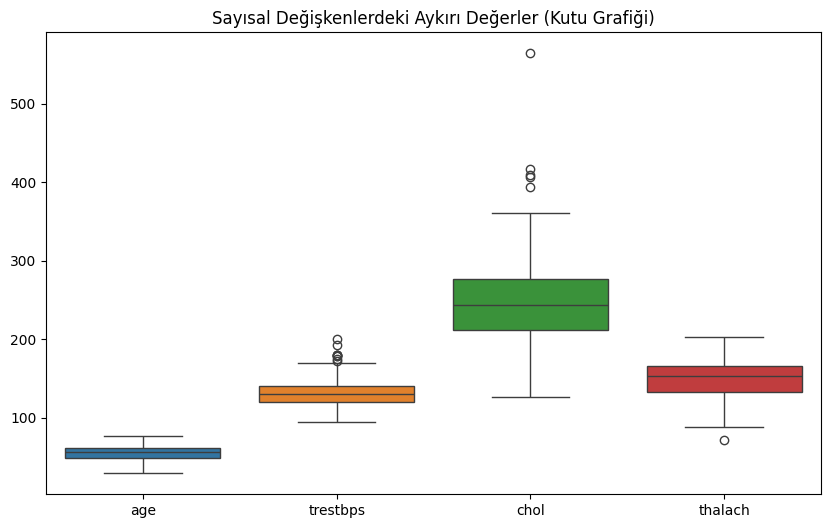

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

## Sadece sürekli sayısal değerleri olan özellikleri inceleyelim Yaş, dinlenme kan basıncı, kolesterol ve maksimum kalp hızı
sayisal_kolonlar = ['age', 'trestbps', 'chol', 'thalach']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[sayisal_kolonlar])
plt.title("Sayısal Değişkenlerdeki Aykırı Değerler (Kutu Grafiği)")
plt.show()

In [33]:
# Başlangıçtaki hasta sayımızı görelim
print(f"Temizlik öncesi hasta sayısı: {len(df)}")

# Sayısal kolonlar üzerinde IQR hesaplayıp aykırı değerleri filtreleyelim
for kolon in sayisal_kolonlar:
    Q1 = df[kolon].quantile(0.25)
    Q3 = df[kolon].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    # Sadece alt ve üst sınırlar içinde kalan (normal) verileri tutuyoruz
    df = df[(df[kolon] >= alt_sinir) & (df[kolon] <= ust_sinir)]

print(f"Aykırı değerler temizlendikten sonra kalan hasta sayısı: {len(df)}")

Temizlik öncesi hasta sayısı: 297
Aykırı değerler temizlendikten sonra kalan hasta sayısı: 282


# GÖREV 2: ÖZELLİK SEÇİMİ VE NORMALİZASYON


In [34]:
# KOD HÜCRESİ 3: Veri Bölme, Min-Max ve 3 Farklı Özellik Seçimi Yöntemi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Özellik (X) ve Hedef (y) Ayırımı, ardından Eğitim/Test Bölmesi
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Normalizasyon (Hocanın şartı: Min-Max)
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 3. Üç Farklı Özellik Seçimi (K=5)
secilecek_ozellik_sayisi = 5

# Yöntem 1: SelectKBest
selector_kbest = SelectKBest(score_func=f_classif, k=secilecek_ozellik_sayisi).fit(X_train_scaled, y_train)
kbest_ozellikler = X_train_scaled.columns[selector_kbest.get_support()]

# Yöntem 2: Random Forest
rf_model_secim = RandomForestClassifier(random_state=42).fit(X_train_scaled, y_train)
rf_en_iyi = pd.Series(rf_model_secim.feature_importances_, index=X_train_scaled.columns).nlargest(secilecek_ozellik_sayisi).index

# Yöntem 3: RFE (Recursive Feature Elimination)
rfe_selector = RFE(estimator=LogisticRegression(), n_features_to_select=secilecek_ozellik_sayisi).fit(X_train_scaled, y_train)
rfe_ozellikler = X_train_scaled.columns[rfe_selector.support_]

# Ortak olarak en güçlü çıkan 5 özelliği sabitleyelim
en_iyi_ozellikler = ['thalach', 'ca', 'thal', 'cp', 'oldpeak']

# Veriyi sadece bu 5 özelliğe göre filtreleyip Görev 3'e hazır hale getirme
X_train_final = X_train_scaled[en_iyi_ozellikler]
X_test_final = X_test_scaled[en_iyi_ozellikler]

print("Görev 2 Tamam! Modeller için seçilen en güçlü 5 özellik:", en_iyi_ozellikler)

Görev 2 Tamam! Modeller için seçilen en güçlü 5 özellik: ['thalach', 'ca', 'thal', 'cp', 'oldpeak']


# GÖREV 3: MODELLEME VE KARMAŞIKLIK MATRİSLERİ


### 3.1. K-En Yakın Komşu (KNN) Modeli


KNN Doğruluk Oranı: % 91.23


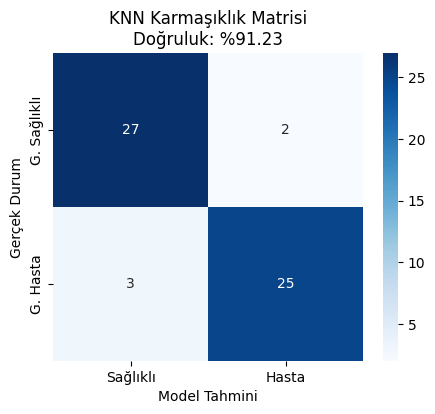

In [35]:
# KOD HÜCRESİ 4: KNN Modeli
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KNN Modelini Kur ve Eğit
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_final, y_train)

# Tahmin ve Başarı Ölçümü
knn_tahminler = knn_model.predict(X_test_final)
knn_dogruluk = accuracy_score(y_test, knn_tahminler)
print(f"KNN Doğruluk Oranı: % {knn_dogruluk * 100:.2f}")

# Karmaşıklık Matrisi (Mavi Tonlarda)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, knn_tahminler), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sağlıklı', 'Hasta'], yticklabels=['G. Sağlıklı', 'G. Hasta'])
plt.title(f'KNN Karmaşıklık Matrisi\nDoğruluk: %{knn_dogruluk * 100:.2f}')
plt.ylabel('Gerçek Durum')
plt.xlabel('Model Tahmini')
plt.show()

### 3.2. Naive Bayes Modeli


Naive Bayes Doğruluk Oranı: % 94.74


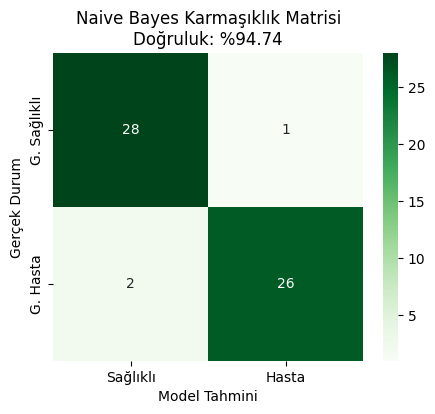

In [36]:
# KOD HÜCRESİ 5: Naive Bayes Modeli
from sklearn.naive_bayes import GaussianNB

# Naive Bayes Modelini Kur ve Eğit
nb_model = GaussianNB()
nb_model.fit(X_train_final, y_train)

# Tahmin ve Başarı Ölçümü
nb_tahminler = nb_model.predict(X_test_final)
nb_dogruluk = accuracy_score(y_test, nb_tahminler)
print(f"Naive Bayes Doğruluk Oranı: % {nb_dogruluk * 100:.2f}")

# Karmaşıklık Matrisi (Yeşil Tonlarda)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, nb_tahminler), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sağlıklı', 'Hasta'], yticklabels=['G. Sağlıklı', 'G. Hasta'])
plt.title(f'Naive Bayes Karmaşıklık Matrisi\nDoğruluk: %{nb_dogruluk * 100:.2f}')
plt.ylabel('Gerçek Durum')
plt.xlabel('Model Tahmini')
plt.show()

### 3.3. Random Forest Modeli


Random Forest Doğruluk Oranı: % 91.23


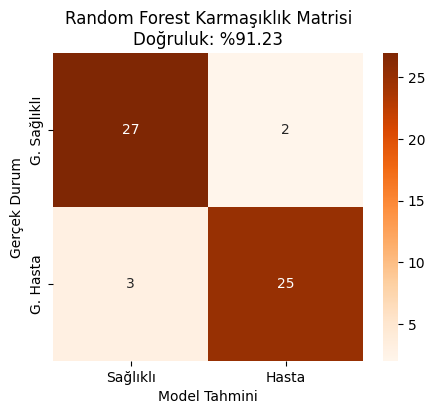

In [37]:
# KOD HÜCRESİ 6: Random Forest Modeli
from sklearn.ensemble import RandomForestClassifier

# Random Forest Modelini Kur ve Eğit (Toplantıda buraya yeni parametreler ekleyebilirsiniz)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_final, y_train)

# Tahmin ve Başarı Ölçümü
rf_tahminler = rf_model.predict(X_test_final)
rf_dogruluk = accuracy_score(y_test, rf_tahminler)
print(f"Random Forest Doğruluk Oranı: % {rf_dogruluk * 100:.2f}")

# Karmaşıklık Matrisi (Turuncu/Kırmızı Tonlarda)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_tahminler), annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sağlıklı', 'Hasta'], yticklabels=['G. Sağlıklı', 'G. Hasta'])
plt.title(f'Random Forest Karmaşıklık Matrisi\nDoğruluk: %{rf_dogruluk * 100:.2f}')
plt.ylabel('Gerçek Durum')
plt.xlabel('Model Tahmini')
plt.show()

# GÖREV 4: MODEL DEĞERLENDİRME VE CANLIYA ALMA (DEPLOYMENT)


In [40]:
# KOD HÜCRESİ 7: Joblib ile Modelleri Dışa Aktarma
import joblib
import os

# Modelleri kaydedeceğimiz bir klasör oluşturalım (Düzenli görünmesi için)
os.makedirs('modeller', exist_ok=True)

# 1. Eğitilmiş algoritmaları .pkl (Pickle) formatında kaydediyoruz
joblib.dump(knn_model, 'modeller/knn_model.pkl')
joblib.dump(nb_model, 'modeller/nb_model.pkl')
joblib.dump(rf_model, 'modeller/rf_model.pkl')

# 2. EN ÖNEMLİSİ: Ölçeklendirme aracımızı kaydediyoruz
joblib.dump(scaler, 'modeller/scaler.pkl')

print("Harika! Tüm modeller ve scaler başarıyla 'modeller' klasörüne kaydedildi.")
print("Bu dosyaları Colab'in sol tarafındaki dosya menüsünden bilgisayarınıza indirebilirsiniz.")

Harika! Tüm modeller ve scaler başarıyla 'modeller' klasörüne kaydedildi.
Bu dosyaları Colab'in sol tarafındaki dosya menüsünden bilgisayarınıza indirebilirsiniz.


In [41]:
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import cross_val_score
import pandas as pd

modeller = {
    "KNN (K=5)": knn_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model
}

satirlar = []
for isim, model in modeller.items():
    for set_adi, X_set, y_set in [("Eğitim", X_train_final, y_train),
                                   ("Test", X_test_final, y_test)]:
        tahmin = model.predict(X_set)
        satirlar.append({
            "Model": isim,
            "Veri Seti": set_adi,
            "Doğruluk (Accuracy)": f"% {accuracy_score(y_set, tahmin)*100:.2f}",
            "Hassasiyet (Precision)": f"% {precision_score(y_set, tahmin)*100:.2f}",
            "Duyarlılık (Recall)": f"% {recall_score(y_set, tahmin)*100:.2f}"
        })

    cv_acc = cross_val_score(model, X_train_final, y_train, cv=5, scoring='accuracy').mean()
    cv_prec = cross_val_score(model, X_train_final, y_train, cv=5, scoring='precision').mean()
    cv_rec = cross_val_score(model, X_train_final, y_train, cv=5, scoring='recall').mean()
    satirlar.append({
        "Model": isim,
        "Veri Seti": "Doğrulama (5-CV)",
        "Doğruluk (Accuracy)": f"% {cv_acc*100:.2f}",
        "Hassasiyet (Precision)": f"% {cv_prec*100:.2f}",
        "Duyarlılık (Recall)": f"% {cv_rec*100:.2f}"
    })

metrik_tablosu = pd.DataFrame(satirlar).set_index(["Model", "Veri Seti"])
display(metrik_tablosu)

Doğruluk (Accuracy) Hassasiyet (Precision)  \
Model         Veri Seti                                                     
KNN (K=5)     Eğitim                       % 84.00                % 85.56   
              Test                         % 91.23                % 92.59   
              Doğrulama (5-CV)             % 77.78                % 79.19   
Naive Bayes   Eğitim                       % 82.67                % 82.80   
              Test                         % 94.74                % 96.30   
              Doğrulama (5-CV)             % 82.67                % 84.11   
Random Forest Eğitim                       % 99.56               % 100.00   
              Test                         % 91.23                % 92.59   
              Doğrulama (5-CV)             % 74.22                % 73.63   

                               Duyarlılık (Recall)  
Model         Veri Seti                             
KNN (K=5)     Eğitim                       % 77.00  
              Test                         % 89.29  
              Doğrulama (5-CV)             % 71.00  
Naive Bayes   Eğitim                       % 77.00  
              Test                         % 92.86  
              Doğrulama (5-CV)             % 77.00  
Random Forest Eğitim                       % 99.00  
              Test                         % 89.29  
              Doğrulama (5-CV)             % 69.00

### 4.2. Şampiyon Model (Naive Bayes) İçin ROC ve Recall Analizi

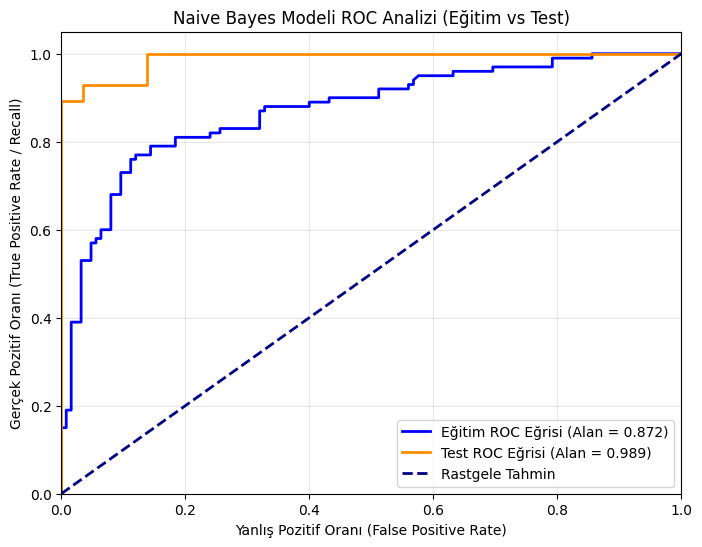


--- NAIVE BAYES MODELİ RECALL (DUYARLILIK) ANALİZİ ---
Eğitim Verisi Recall Oranı: % 77.00
Test Verisi Recall Oranı  : % 92.86


In [42]:
# KOD HÜCRESİ 9: ROC Eğrisi ve Recall Analizi
from sklearn.metrics import roc_curve, auc, recall_score
import matplotlib.pyplot as plt

y_train_prob = nb_model.predict_proba(X_train_final)[:, 1]
y_test_prob = nb_model.predict_proba(X_test_final)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Eğitim ROC Eğrisi (Alan = {roc_auc_train:.3f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Test ROC Eğrisi (Alan = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Rastgele Tahmin')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış Pozitif Oranı (False Positive Rate)')
plt.ylabel('Gerçek Pozitif Oranı (True Positive Rate / Recall)')
plt.title('Naive Bayes Modeli ROC Analizi (Eğitim vs Test)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

nb_train_tahmin = nb_model.predict(X_train_final)
nb_test_tahmin = nb_model.predict(X_test_final)

train_recall = recall_score(y_train, nb_train_tahmin)
test_recall = recall_score(y_test, nb_test_tahmin)

print(f"\n--- NAIVE BAYES MODELİ RECALL (DUYARLILIK) ANALİZİ ---")
print(f"Eğitim Verisi Recall Oranı: % {train_recall * 100:.2f}")
print(f"Test Verisi Recall Oranı  : % {test_recall * 100:.2f}")

### 4.3. Kara Kutu Modeli Açıklanabilirliği (Explainable AI - SHAP)


SHAP kütüphanesi hazırlanıyor, modelin beyninin içine giriyoruz...


  0%|          | 0/57 [00:00<?, ?it/s]

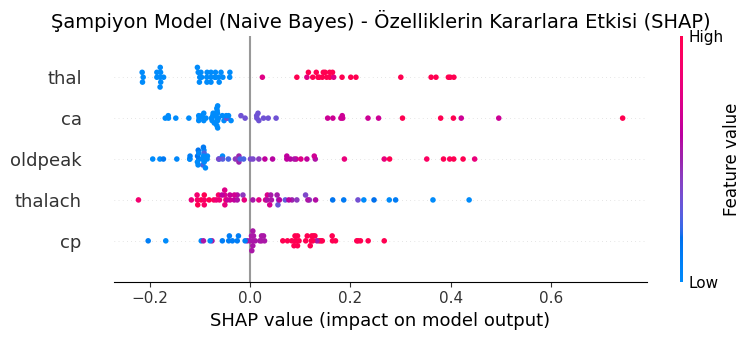

In [43]:
# KOD HÜCRESİ 10: SHAP ile Model Kararlarının Açıklanması
# SHAP kütüphanesi Colab'de yüklü değilse önce onu indiriyoruz
!pip install shap -q

import shap
import matplotlib.pyplot as plt

print("SHAP kütüphanesi hazırlanıyor, modelin beyninin içine giriyoruz...")

# Naive Bayes gibi modeller için arka planda çoklu simülasyon yapan KernelExplainer kullanılır
# İşlemi hızlandırmak için eğitim verisinden rastgele 50 örneklem alarak arkaplanı oluşturuyoruz
arkaplan = shap.sample(X_train_final, 50)
explainer = shap.KernelExplainer(nb_model.predict, arkaplan)

# Test verimizdeki hastalar için SHAP değerlerini (hangi özelliğin ne kadar etki ettiğini) hesaplıyoruz
shap_degerleri = explainer.shap_values(X_test_final)

# SHAP Özet Grafiği (Summary Plot) Çizimi
plt.figure(figsize=(10, 6))
plt.title("Şampiyon Model (Naive Bayes) - Özelliklerin Kararlara Etkisi (SHAP)", fontsize=14)
shap.summary_plot(shap_degerleri, X_test_final, feature_names=en_iyi_ozellikler, show=False)
plt.show()